# Map projections at a glance

`x4c.subplots()` lays out a grid of Cartopy axes from a name per panel — any
projection class Cartopy knows, plus its `projs_kws`. `latlon_range` crops.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
ts_path = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.TS.000101-000512.nc',
)
ds = x4c.open_dataset(ts_path, comp='atm', grid='ne16np4', vn='TS', shift_time=True)

ssh_path = os.path.join(
    case_dir, 'ocn', 'proc', 'tseries', 'month_1',
    f'{casename}.pop.h.SSH.000101-000512.nc',
)
ds_ssh = x4c.open_dataset(ssh_path, comp='ocn', grid='g16', vn='SSH', shift_time=True)
ssv = ds_ssh.x.regrid().x.da.mean('time')
da = ds.x.da.x.annualize().mean('time')

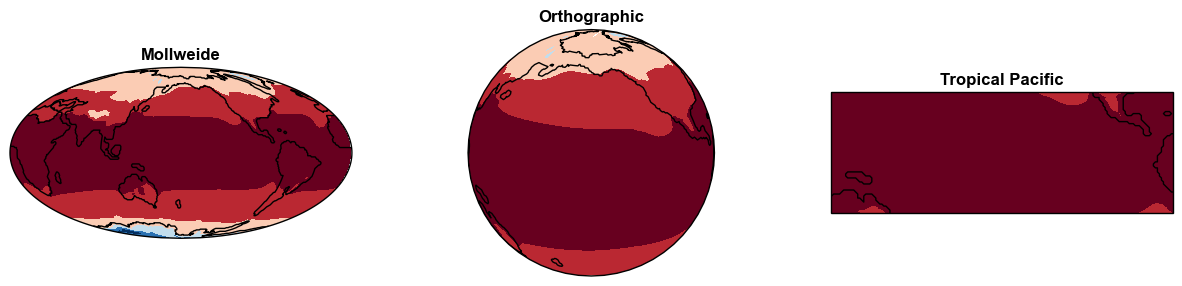

In [3]:
ax_loc = {'a': (0, 0), 'b': (0, 1), 'c': (0, 2)}
projs = {'a': 'Mollweide', 'b': 'Orthographic', 'c': 'PlateCarree'}
projs_kws = {'a': {'central_longitude': 180},
             'b': {'central_longitude': 200, 'central_latitude': 20},
             'c': {'central_longitude': 180}}
fig, axd = x4c.subplots(1, 3, ax_loc=ax_loc, projs=projs, projs_kws=projs_kws,
                        figsize=(15, 3.2), wspace=0.2)

da.x.plot(ax=axd['a'], ssv=ssv, title='Mollweide', add_colorbar=False)
da.x.plot(ax=axd['b'], ssv=ssv, title='Orthographic', add_colorbar=False)
da.x.plot(ax=axd['c'], ssv=ssv, title='Tropical Pacific',
          latlon_range=(-30, 30, 120, 290), add_colorbar=False)
x4c.showfig(fig)